# 05 — Candidate Pool Active Pair Generator

Цель эксперимента — проверить стратегию `candidate_pool_active`, которая генерирует смешанный пул A/B-вопросов из разных источников и выбирает самый полезный вопрос по эвристическому `question_score`.

В отличие от `semantic_active_v21`, новая стратегия не ограничивается только semantic-направлениями. В пул входят:

- random multidimensional directions;
- uncertainty-axis questions;
- semantic v2.1 directions.

Важно: это всё ещё **не Preference Model**. Стратегия выбирает не то, что точно понравится пользователю, а вопрос, который должен дать максимум информации о preference state.

In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from personalization.analysis import (
    DEFAULT_STRATEGY_ORDER,
    display_strategy_name,
    display_group_name,
    merge_sessions_with_user_metadata,
    summarize_by_group,
    winners_by_group,
    win_rates_vs_baseline_by_group,
    compare_two_strategies_by_group,
    win_rate_between_strategies_by_group,
    plot_group_metric_bars,
    plot_win_rate_bars,
    plot_strategy_improvement_bars,
)
from personalization.batch_eval import (
    run_batch_on_dataset,
    save_batch_outputs,
    summarize_by_strategy,
    win_rates_vs_baseline,
)
from personalization.plotting import use_article_style, save_figure
from personalization.synthetic_dataset import (
    dataset_metadata,
    generate_synthetic_users_dataset,
    load_synthetic_users_dataset,
    save_synthetic_users_dataset,
)

use_article_style()

DATASET_PATH = PROJECT_ROOT / "outputs" / "datasets" / "synthetic_users_v21.csv"
METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
METRICS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Загрузка fixed synthetic user dataset

Если датасет ещё не был создан, ноутбук автоматически сгенерирует `synthetic_users_v21.csv`.

In [3]:
if not DATASET_PATH.exists():
    dataset = generate_synthetic_users_dataset(
        n_per_mode=100,
        seed=42,
        noise_std=0.05,
    )
    save_synthetic_users_dataset(
        dataset=dataset,
        dataset_path=DATASET_PATH,
        metadata_path=DATASET_PATH.with_suffix(".metadata.json"),
        metadata=dataset_metadata(
            dataset_name=DATASET_PATH.stem,
            n_per_mode=100,
            seed=42,
            noise_std=0.05,
            importance_sigma=0.35,
        ),
    )
else:
    dataset = load_synthetic_users_dataset(DATASET_PATH)

dataset["target_mode"].value_counts()

target_mode
random8d       100
semantic4d     100
semantic6d     100
archetype8d    100
Name: count, dtype: int64

## 2. Batch-сравнение стратегий

Сравниваем `candidate_pool_active` с основными предыдущими стратегиями.

In [4]:
STRATEGIES = [
    "random",
    "uncertainty_axis",
    "semantic_control_v21",
    "semantic_active_v21",
    "candidate_pool_active",
    "hybrid_active_v21",
]

sessions_df, curves = run_batch_on_dataset(
    dataset=dataset,
    strategies=STRATEGIES,
    n_steps=25,
    step_scale=0.6,
    lr=0.25,
)

strategy_summary = summarize_by_strategy(sessions_df)
win_rates = win_rates_vs_baseline(sessions_df, baseline="random")

save_batch_outputs(
    sessions=sessions_df,
    strategy_summary=strategy_summary,
    win_rates=win_rates,
    output_dir=METRICS_DIR,
    prefix="notebook_v31_candidate_pool_active",
)

sessions_with_meta = merge_sessions_with_user_metadata(sessions_df, dataset)
sessions_with_meta.to_csv(METRICS_DIR / "notebook_v31_candidate_pool_active_sessions_with_meta.csv", index=False)

strategy_summary

,target_mode,strategy,users,mean_initial_distance,mean_final_distance,std_final_distance,mean_best_distance,mean_mean_distance,mean_improvement_pct,std_improvement_pct
3,archetype8d,semantic_active_v21,100,1.102635,0.378947,0.133465,0.280561,0.578662,57.677776,24.221786
4,archetype8d,semantic_control_v21,100,1.102635,0.476987,0.164772,0.322239,0.616510,44.705813,38.626852
0,archetype8d,candidate_pool_active,100,1.102635,0.486661,0.172475,0.348718,0.641229,43.705720,36.310704
1,archetype8d,hybrid_active_v21,100,1.102635,0.513053,0.170899,0.390215,0.700265,40.332236,39.495013
5,archetype8d,uncertainty_axis,100,1.102635,0.533740,0.259131,0.443866,0.760355,41.021812,35.416559
2,archetype8d,random,100,1.102635,0.567765,0.214612,0.472785,0.770912,35.841547,41.039317
11,random8d,uncertainty_axis,100,2.212002,0.985761,0.415946,0.960684,1.546811,56.663880,11.459939
6,random8d,candidate_pool_active,100,2.212002,0.992587,0.426057,0.975984,1.562093,56.254310,11.525204
8,random8d,random,100,2.212002,0.996708,0.402072,0.979050,1.572826,55.800212,11.632861
7,random8d,hybrid_active_v21,100,2.212002,1.073537,0.428281,1.042458,1.571624,52.232727,12.656742


In [5]:
win_rates

,target_mode,strategy,baseline,win_rate_final_distance,win_rate_best_distance
0,archetype8d,candidate_pool_active,random,0.63,0.82
1,archetype8d,hybrid_active_v21,random,0.60,0.62
2,archetype8d,semantic_active_v21,random,0.88,0.94
3,archetype8d,semantic_control_v21,random,0.65,0.79
4,archetype8d,uncertainty_axis,random,0.61,0.58
5,random8d,candidate_pool_active,random,0.57,0.60
6,random8d,hybrid_active_v21,random,0.45,0.47
7,random8d,semantic_active_v21,random,0.11,0.12
8,random8d,semantic_control_v21,random,0.08,0.08
9,random8d,uncertainty_axis,random,0.53,0.51


## 3. Победители по режимам target

In [6]:
target_mode_summary = summarize_by_group(sessions_with_meta, ["target_mode"])
target_mode_winners = winners_by_group(target_mode_summary, ["target_mode"])
target_mode_win_rates = win_rates_vs_baseline_by_group(sessions_with_meta, ["target_mode"])

target_mode_summary.to_csv(METRICS_DIR / "notebook_v31_target_mode_group_summary.csv", index=False)
target_mode_winners.to_csv(METRICS_DIR / "notebook_v31_target_mode_winners.csv", index=False)
target_mode_win_rates.to_csv(METRICS_DIR / "notebook_v31_target_mode_win_rates.csv", index=False)

target_mode_winners

,target_mode,winner_strategy,users,winner_mean_final_distance
0,archetype8d,semantic_active_v21,100,0.378947
1,semantic4d,semantic_active_v21,100,0.410014
2,semantic6d,semantic_active_v21,100,0.551607
3,random8d,uncertainty_axis,100,0.985761


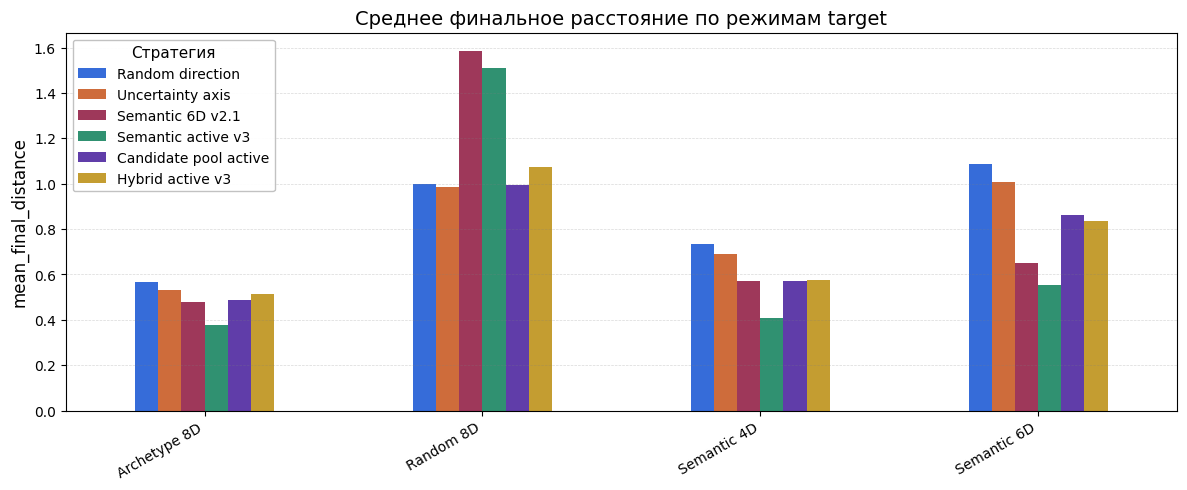

In [7]:
fig, ax = plot_group_metric_bars(
    target_mode_summary,
    group_col="target_mode",
    metric="mean_final_distance",
    strategy_order=STRATEGIES,
    title="Среднее финальное расстояние по режимам target",
    figsize=(12, 5),
)
ax.set_xticklabels([display_group_name(t.get_text()) for t in ax.get_xticklabels()])
save_figure(fig, FIGURES_DIR / "v31_mean_final_distance_by_target_mode.png")
plt.show()

## 4. Средние кривые сходимости

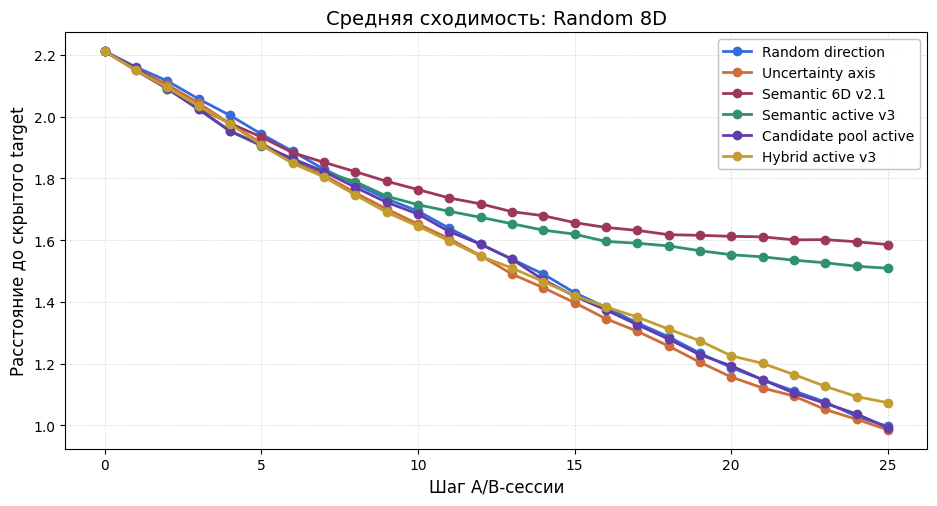

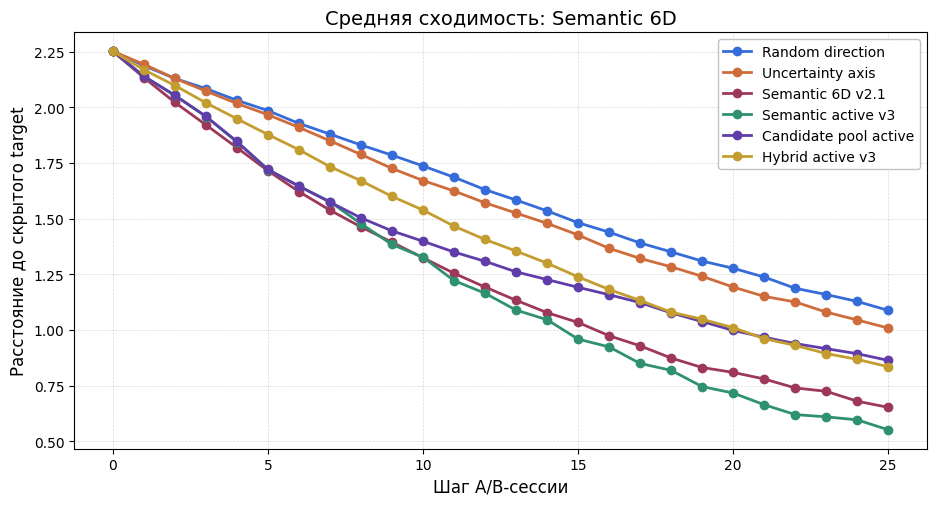

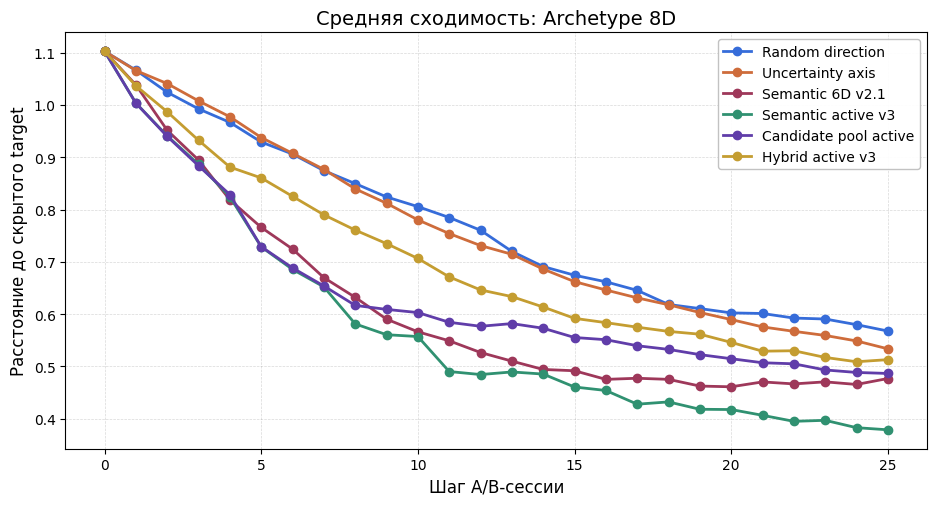

In [8]:
def plot_mean_convergence(curves: dict, target_mode: str, strategies: list[str]):
    fig, ax = plt.subplots(figsize=(9.5, 5.2), facecolor="white")

    for strategy in strategies:
        if strategy not in curves[target_mode]:
            continue
        values = curves[target_mode][strategy]
        mean_curve = values.mean(axis=0)
        steps = np.arange(len(mean_curve))
        ax.plot(
            steps,
            mean_curve,
            marker="o",
            linewidth=2,
            label=display_strategy_name(strategy),
        )

    ax.set_title(f"Средняя сходимость: {display_group_name(target_mode)}")
    ax.set_xlabel("Шаг A/B-сессии")
    ax.set_ylabel("Расстояние до скрытого target")
    ax.grid(True, alpha=0.3, linestyle="--", color="gray")
    ax.legend(frameon=True, facecolor="white", edgecolor="0.75")
    for spine in ax.spines.values():
        spine.set_color("black")
    plt.tight_layout()
    return fig, ax

for mode in ["random8d", "semantic6d", "archetype8d"]:
    fig, ax = plot_mean_convergence(curves, mode, STRATEGIES)
    save_figure(fig, FIGURES_DIR / f"v31_mean_convergence_{mode}.png")
    plt.show()

## 5. Анализ realistic users: intensity и archetype

In [9]:
archetype_sessions = sessions_with_meta[sessions_with_meta["target_mode"] == "archetype8d"].copy()

intensity_summary = summarize_by_group(archetype_sessions, ["intensity_label"])
intensity_win_rates = win_rates_vs_baseline_by_group(archetype_sessions, ["intensity_label"])

intensity_summary.to_csv(METRICS_DIR / "notebook_v31_intensity_group_summary.csv", index=False)
intensity_win_rates.to_csv(METRICS_DIR / "notebook_v31_intensity_win_rates.csv", index=False)

intensity_summary.head()

,intensity_label,strategy,users,mean_initial_distance,mean_final_distance,std_final_distance,mean_best_distance,mean_mean_distance,mean_improvement_pct,std_improvement_pct
3,extreme,semantic_active_v21,16,1.382814,0.458711,0.254879,0.372386,0.785348,60.409439,19.359674
4,extreme,semantic_control_v21,16,1.382814,0.547728,0.250569,0.455746,0.825583,51.460459,23.859111
0,extreme,candidate_pool_active,16,1.382814,0.608300,0.296399,0.458956,0.848865,44.866022,26.857893
1,extreme,hybrid_active_v21,16,1.382814,0.621731,0.305688,0.537064,0.933360,44.116070,28.928784
2,extreme,random,16,1.382814,0.627439,0.327190,0.546072,0.954679,45.520765,25.138565


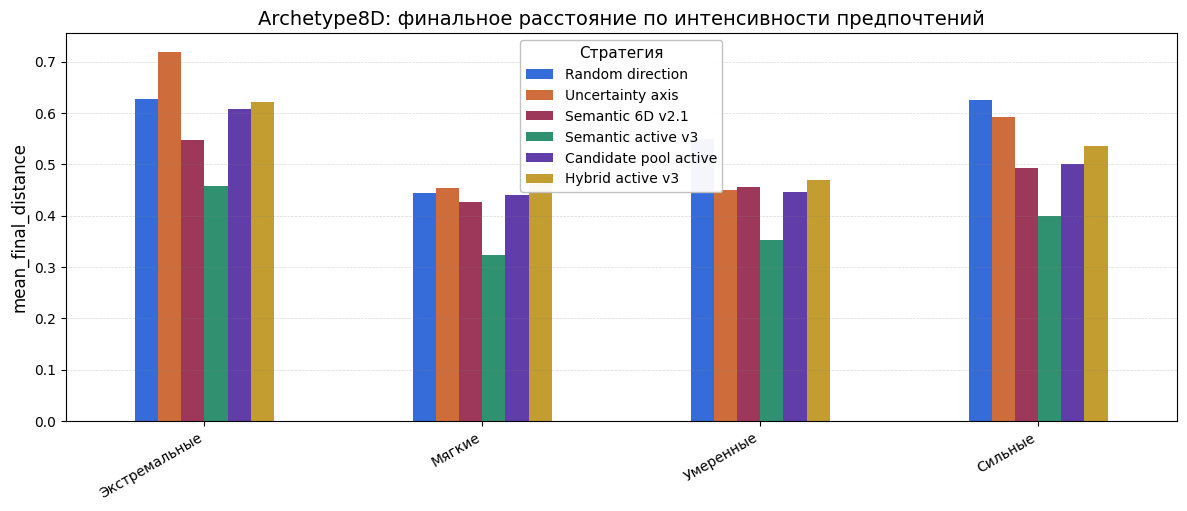

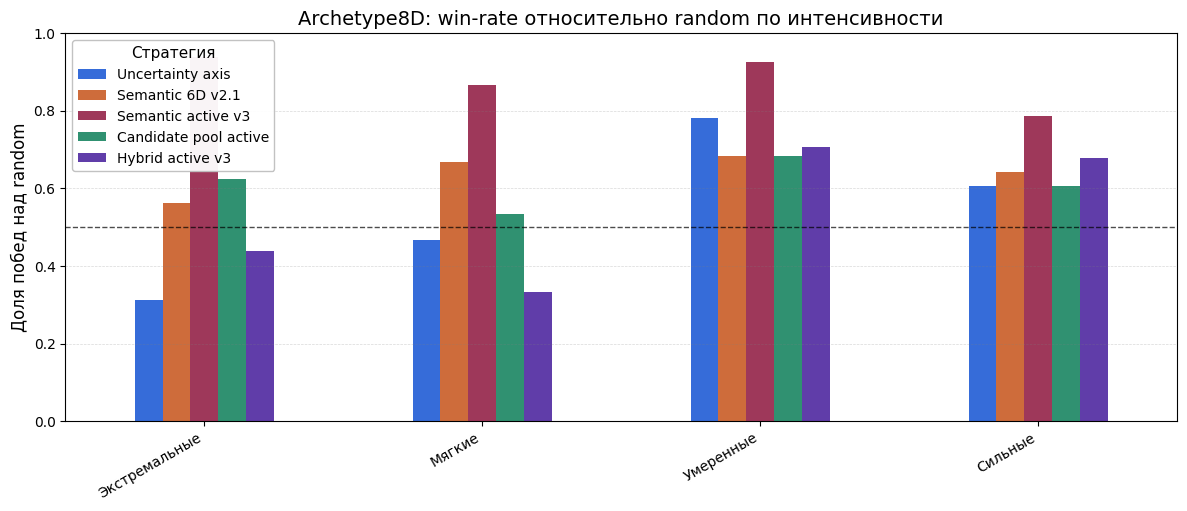

In [10]:
fig, ax = plot_group_metric_bars(
    intensity_summary,
    group_col="intensity_label",
    metric="mean_final_distance",
    strategy_order=STRATEGIES,
    title="Archetype8D: финальное расстояние по интенсивности предпочтений",
    figsize=(12, 5),
)
ax.set_xticklabels([display_group_name(t.get_text()) for t in ax.get_xticklabels()])
save_figure(fig, FIGURES_DIR / "v31_archetype_intensity_mean_final_distance.png")
plt.show()

fig, ax = plot_win_rate_bars(
    intensity_win_rates,
    group_col="intensity_label",
    strategy_order=STRATEGIES,
    title="Archetype8D: win-rate относительно random по интенсивности",
    figsize=(12, 5),
)
ax.set_xticklabels([display_group_name(t.get_text()) for t in ax.get_xticklabels()])
save_figure(fig, FIGURES_DIR / "v31_archetype_intensity_win_rate.png")
plt.show()

In [11]:
main_archetype_summary = summarize_by_group(archetype_sessions, ["main_archetype"])
main_archetype_win_rates = win_rates_vs_baseline_by_group(archetype_sessions, ["main_archetype"])

main_archetype_summary.to_csv(METRICS_DIR / "notebook_v31_main_archetype_group_summary.csv", index=False)
main_archetype_win_rates.to_csv(METRICS_DIR / "notebook_v31_main_archetype_win_rates.csv", index=False)

main_archetype_summary.head()

,main_archetype,strategy,users,mean_initial_distance,mean_final_distance,std_final_distance,mean_best_distance,mean_mean_distance,mean_improvement_pct,std_improvement_pct
3,bass_lover,semantic_active_v21,7,1.077502,0.332930,0.104913,0.258589,0.503561,67.679806,10.072760
2,bass_lover,random,7,1.077502,0.397822,0.135922,0.357954,0.691390,58.330740,29.236898
1,bass_lover,hybrid_active_v21,7,1.077502,0.440470,0.138571,0.375178,0.641995,54.351592,22.581634
5,bass_lover,uncertainty_axis,7,1.077502,0.454155,0.144945,0.414871,0.706812,55.433790,16.929935
0,bass_lover,candidate_pool_active,7,1.077502,0.463681,0.092357,0.298900,0.573625,54.418607,13.452877


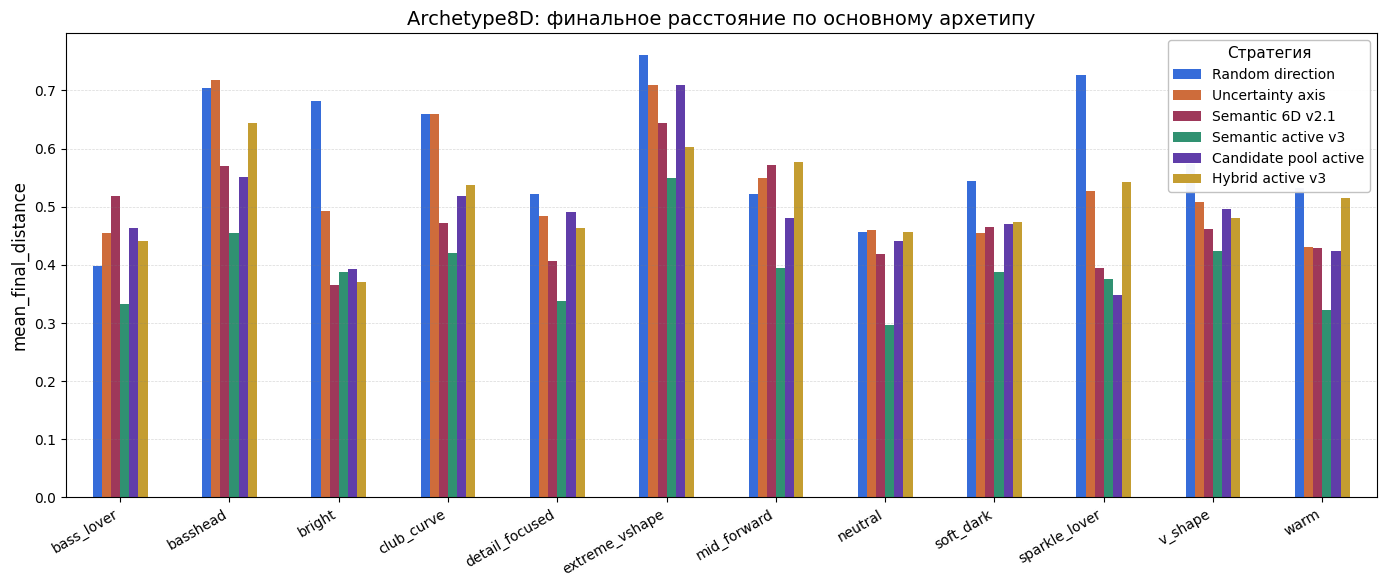

In [12]:
fig, ax = plot_group_metric_bars(
    main_archetype_summary,
    group_col="main_archetype",
    metric="mean_final_distance",
    strategy_order=STRATEGIES,
    title="Archetype8D: финальное расстояние по основному архетипу",
    figsize=(14, 6),
)
save_figure(fig, FIGURES_DIR / "v31_main_archetype_mean_final_distance.png")
plt.show()

## 6. Candidate pool active vs Semantic active

Сравним новую стратегию `candidate_pool_active` с текущей сильной стратегией `semantic_active_v21`.

In [13]:
candidate_vs_v3_by_archetype = compare_two_strategies_by_group(
    main_archetype_summary,
    group_col="main_archetype",
    old_strategy="semantic_active_v21",
    new_strategy="candidate_pool_active",
    metric="mean_final_distance",
)

candidate_vs_v3_win_rates = win_rate_between_strategies_by_group(
    archetype_sessions,
    group_cols=["main_archetype"],
    strategy_a="candidate_pool_active",
    strategy_b="semantic_active_v21",
    metric="final_distance",
)

candidate_vs_v3_by_archetype.to_csv(METRICS_DIR / "notebook_v31_candidate_vs_v3_by_archetype.csv", index=False)
candidate_vs_v3_win_rates.to_csv(METRICS_DIR / "notebook_v31_candidate_vs_v3_win_rates_by_archetype.csv", index=False)

candidate_vs_v3_by_archetype

,main_archetype,semantic_active_v21_mean_final_distance,candidate_pool_active_mean_final_distance,improvement_abs,improvement_pct,winner
0,sparkle_lover,0.376305,0.348940,0.027365,7.271928,candidate_pool_active
1,bright,0.387623,0.392409,-0.004786,-1.234763,semantic_active_v21
2,v_shape,0.424585,0.496773,-0.072187,-17.001857,semantic_active_v21
3,soft_dark,0.387104,0.469511,-0.082407,-21.288146,semantic_active_v21
4,mid_forward,0.394244,0.480191,-0.085947,-21.800391,semantic_active_v21
5,basshead,0.455611,0.551883,-0.096272,-21.130270,semantic_active_v21
6,club_curve,0.419631,0.518104,-0.098473,-23.466468,semantic_active_v21
7,warm,0.323048,0.424104,-0.101057,-31.282281,semantic_active_v21
8,bass_lover,0.332930,0.463681,-0.130751,-39.272692,semantic_active_v21
9,neutral,0.297099,0.440941,-0.143842,-48.415406,semantic_active_v21


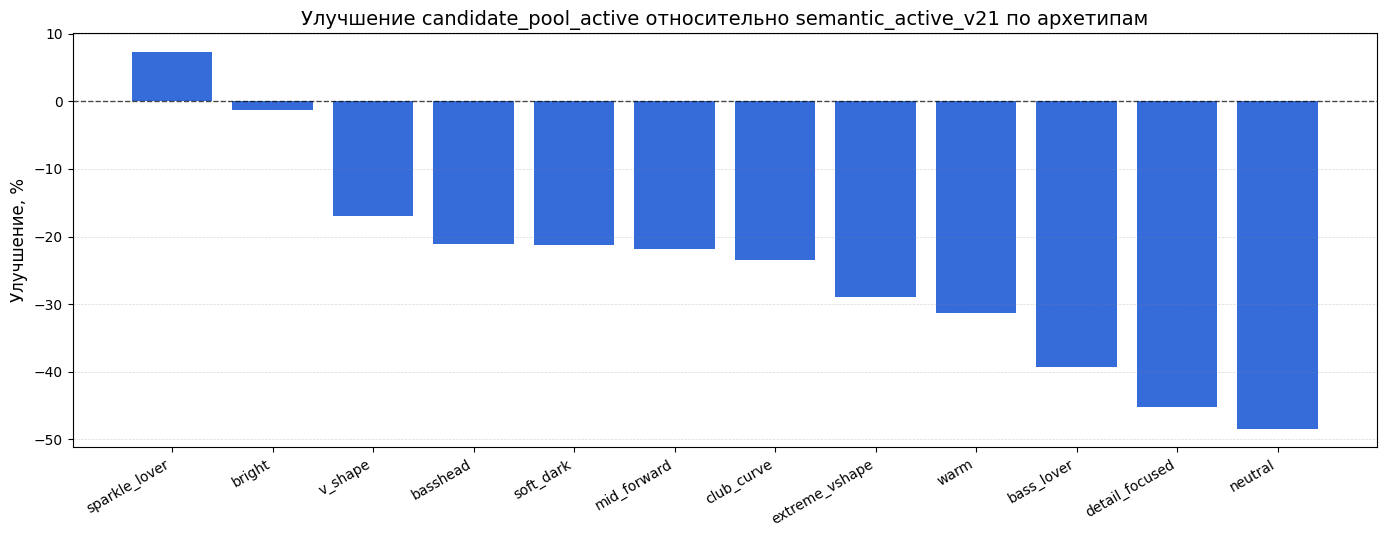

In [14]:
fig, ax = plot_strategy_improvement_bars(
    candidate_vs_v3_by_archetype,
    group_col="main_archetype",
    value_col="improvement_pct",
    title="Улучшение candidate_pool_active относительно semantic_active_v21 по архетипам",
    figsize=(14, 5.5),
)
save_figure(fig, FIGURES_DIR / "v31_candidate_vs_v3_improvement_by_archetype.png")
plt.show()

## Вывод по candidate_pool_active

В данном эксперименте была проверена стратегия `candidate_pool_active`, которая генерирует смешанный пул A/B-вопросов из random directions, uncertainty-axis questions и semantic directions, после чего выбирает пару по question-usefulness score.

Результаты показывают, что `candidate_pool_active` улучшает random baseline в большинстве режимов. В режиме `random8d` стратегия почти сравнялась с лучшей `uncertainty_axis`, а в режиме `archetype8d` достигла меньшего mean final distance, чем random baseline. Это подтверждает, что смешанный candidate-pool подход может работать как более универсальный Pair Generator.

Однако `candidate_pool_active` не превзошла `semantic_active_v21` на структурированных режимах `semantic4d`, `semantic6d` и `archetype8d`. На реалистичном `archetype8d`-наборе `semantic_active_v21` показала mean final distance около `0.379`, тогда как `candidate_pool_active` — около `0.487`. Анализ по архетипам также показал, что `semantic_active_v21` лучше почти для всех пользовательских типов.

Таким образом, текущая версия `candidate_pool_active` является полезным универсальным baseline, но для реалистичных музыкально структурированных пользователей специализированная стратегия `semantic_active_v21` остаётся более эффективной. Вероятная причина состоит в том, что добавление random и axis-кандидатов размывает semantic-поиск, который хорошо соответствует структуре `archetype8d`-предпочтений.

Следующим шагом может быть настройка весов candidate-pool score или разработка adaptive routing-подхода, который будет выбирать между `semantic_active_v21` и более универсальными candidate-pool вопросами в зависимости от типа неопределённости и текущей траектории сессии.